In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.diagnostic import linear_reset

from scipy.optimize import curve_fit
from src.config import get_birth_values
import src.config as cfg

    
np.set_printoptions(suppress=True)
pd.options.display.max_columns = None
pd.options.display.max_colwidth = None
pd.options.display.max_rows = None


In [2]:

mod_quarter_const = cfg.mod_quarter_const  # Model 4: y = b*x^(1/4) + c
# Use base config colors explicitly so panel 5 always has Mouse, Mouse_O, Mouse_WO and Rat.
colors_cfg = dict(cfg.colors)

# Fitted parameters for Model 4 (from paper2potencia WLS separate fits), sourced from src/config.py
model4_params = {
    'Rat': cfg.params_quarter_plus_c['rat'],
    'Mouse': cfg.params_quarter_plus_c['mouse'],
}

In [3]:
df = pd.read_csv('data/dataset_mrh_0.9.csv')
#df.head()


In [4]:
df_pivot = df.pivot_table(index='Parameter', columns='Species', values='DAF', aggfunc='mean').reset_index()
human_birth, mouse_birth, rat_birth = get_birth_values(df_pivot)
df_pivot.head()


Species,Parameter,Human,Mouse,Rat
0,1st 7 rills chondrified and in contact with sternum,51.0,14.50,NaN
1,1st and 2nd pharyngeal pouches,23.0,8.33,NaN
2,1st cartilage in otic capsule,48.0,14.50,NaN
3,1st pharyngeal pouch,21.0,8.33,NaN
4,3 bronchial areas in right lung,35.0,11.50,NaN


open dataset of develoipmental milestones of humans mouse and rats reveals a patern of scale invarianse 

In [5]:
# Datos base para los ajustes entre humano y roedores
fit_mouse = df_pivot[['Human', 'Mouse']].dropna()
fit_rat = df_pivot[['Human', 'Rat']].dropna()



--- Mouse ---
  Original WLS : y = 8.7156*X + -9.5489
  Linear WLS   : y = 8.7156*X + -9.5489  (Should be nearly identical)
  R² (Linear)  : 0.7496
  RMSE (Linear): 5.4451
  Quadratic    : RMSE=6.2972, ΔAIC(Linear-Quad)=-0.94
  Is X^2 term significant (p<0.05)? : No (p=0.3087)
  RESET F=60.9904, p=0.0000
  ✅ Diagnostic: The x^0.25 transform appears to remove main curvature.
--------------------------------------------------
--- Rat ---
  Original WLS : y = 10.4042*X + -12.5260
  Linear WLS   : y = 10.4042*X + -12.5260  (Should be nearly identical)
  R² (Linear)  : 0.7596
  RMSE (Linear): 6.9857
  Quadratic    : RMSE=6.3518, ΔAIC(Linear-Quad)=-0.02
  Is X^2 term significant (p<0.05)? : No (p=0.1637)
  RESET F=12.2660, p=0.0000
  ✅ Diagnostic: The x^0.25 transform appears to remove main curvature.
--------------------------------------------------


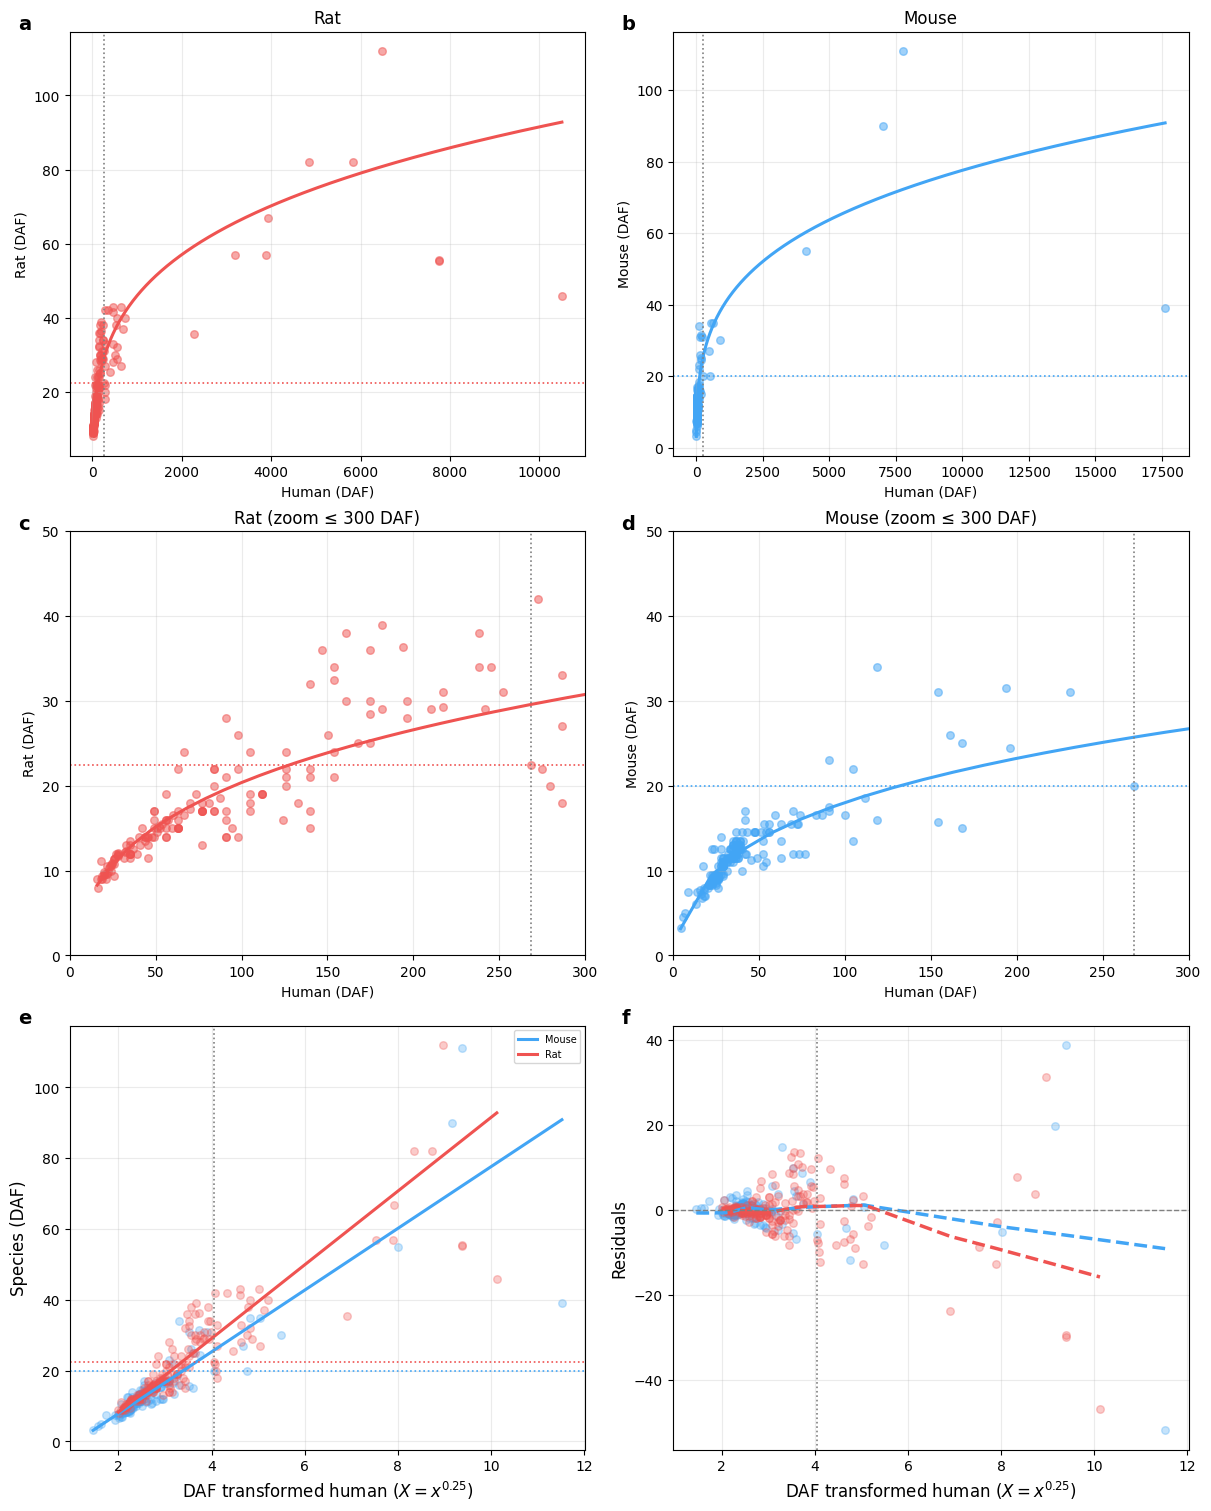

In [6]:
FS_LABEL, FS_TICK, FS_LEGEND, FS_PANEL = 12, 10, 9, 14

# Combined panel: rows 1-2 = scatter + fitted line (Model 4: y = b*x^0.25 + c, fixed params),
# row 3 = linearity assessment (X = Human^0.25) and residuals (both species).
fig, axes = plt.subplots(3, 2, figsize=(12, 15), constrained_layout=True)

species_config = [
    ('Rat', fit_rat, 'rat'),
    ('Mouse', fit_mouse, 'mouse'),
]

birth_by_species = {'Rat': rat_birth, 'Mouse': mouse_birth}

for col, (species, fit_df, param_key) in enumerate(species_config):
    x = fit_df['Human'].to_numpy(dtype=float)
    y = fit_df[species].to_numpy(dtype=float)
    color = cfg.colors.get(species)

    params = cfg.params_quarter_plus_c[param_key]
    b_coef, c_coef = params['b'], params['c']

    x_line = np.linspace(x.min(), x.max(), 1000)
    y_line = cfg.mod_quarter_const(x_line, b_coef, c_coef)

    for row, xlim in enumerate([None, (0, 300)]):
        ax = axes[row, col]
        ax.scatter(x, y, color=color, alpha=0.5, s=30)
        ax.plot(x_line, y_line, color=color, linewidth=2.2)

        # Birth reference lines (human on x-axis, species on y-axis)
        ax.axvline(human_birth, color='grey', linestyle=':', linewidth=1.2)
        ax.axhline(birth_by_species[species], color=color, linestyle=':', linewidth=1.2)

        ax.set_xlabel('Human (DAF)')
        ax.set_ylabel(f'{species} (DAF)')
        title = species if xlim is None else f'{species} (zoom \u2264 300 DAF)'
        ax.set_title(title)
        ax.grid(True, alpha=0.25)
        if xlim is not None:
            ax.set_xlim(*xlim)
            ax.set_ylim(0, 50)

# Row 3: linearity assessment (left) and residuals (right), shared by both species
ax_fit, ax_res = axes[2, 0], axes[2, 1]

for species in ['Mouse', 'Rat']:
    sel = model4_params[species]
    b_coef = float(sel['b'])
    c_orig = float(sel['c'])

    human = df_pivot['Human'].to_numpy(dtype=float)
    y_spec = df_pivot[species].to_numpy(dtype=float)

    mask = np.isfinite(human) & np.isfinite(y_spec) & (human > 0)
    if mask.sum() <= 4:
        print(f'Not enough valid points for {species}.')
        continue

    h = human[mask]
    y = y_spec[mask]

    # Pure transformation (X = x^0.25)
    X = np.power(h, 0.25)

    # ======================================================================
    # REPLICATION OF WLS WEIGHT LOGIC (from cell 09.5)
    # ======================================================================
    try:
        X_ols_const = sm.add_constant(X)
        ols_fit = sm.OLS(y, X_ols_const).fit()
        y_ols_pred = ols_fit.predict(X_ols_const)

        resid2 = np.maximum((y - y_ols_pred) ** 2, np.finfo(float).eps)
        Z = sm.add_constant(np.log(np.maximum(h, np.finfo(float).eps)))
        var_fit = sm.OLS(np.log(resid2), Z).fit()
        sigma2 = np.maximum(np.exp(var_fit.predict(Z)), np.finfo(float).eps)
        sigma = np.sqrt(sigma2)

        w = 1.0 / sigma2
    except Exception as e:
        print(f"⚠️ Error calculating WLS weights for {species} ({e}). Using OLS (equal weights).")
        w = None
    # ======================================================================

    color = cfg.colors.get(species, None)

    # Linear WLS model
    X_lin_const = sm.add_constant(X)
    mod_lin = sm.WLS(y, X_lin_const, weights=w).fit()
    slope_lin, intercept_lin = mod_lin.params[1], mod_lin.params[0]
    y_pred_lin = mod_lin.predict(X_lin_const)
    resid_lin = y - y_pred_lin

    # Quadratic (for diagnostics)
    X_quad = np.column_stack((X, X**2))
    X_quad_const = sm.add_constant(X_quad)
    mod_quad = sm.WLS(y, X_quad_const, weights=w).fit()
    y_pred_quad = mod_quad.predict(X_quad_const)

    # LOESS smoothing for the residuals (resid vs X)
    try:
        loess_frac = 0.8
        loess_res = lowess(resid_lin, X, frac=loess_frac, return_sorted=True)
    except Exception:
        loess_res = None

    # Plot: left axis (data and linear fit)
    ax_fit.scatter(X, y, color=color, alpha=0.3, s=30)
    X_line_plot = np.linspace(np.min(X), np.max(X), 200)
    ax_fit.plot(X_line_plot, mod_lin.predict(sm.add_constant(X_line_plot)), color=color, linewidth=2.2, label=f'{species}')

    # Plot residuals on the right axis (both species share the residual panel)
    ax_res.scatter(X, resid_lin, color=color, alpha=0.3, s=30)
    if loess_res is not None:
        ax_res.plot(loess_res[:, 0], loess_res[:, 1], color=color, linewidth=2.5, linestyle='--')

    # Birth reference line for this species (y-axis on ax_fit)
    ax_fit.axhline(birth_by_species[species], color=color, linestyle=':', linewidth=1.2)

    # Print diagnostics per species
    ss_res_lin = np.sum(resid_lin**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2_lin = 1 - (ss_res_lin / ss_tot)
    rmse_lin = np.sqrt(np.mean(resid_lin**2))
    rmse_quad = np.sqrt(np.mean((y - y_pred_quad)**2))
    aic_quad = mod_quad.aic
    aic_lin = mod_lin.aic
    delta_aic = aic_lin - aic_quad
    p_val_x2 = mod_quad.pvalues[2] if len(mod_quad.pvalues) > 2 else np.nan
    sig_x2 = "Yes" if pd.notna(p_val_x2) and p_val_x2 < 0.05 else "No"

    try:
        reset_res = linear_reset(mod_lin, power=3, use_f=True)
        f_reset = float(reset_res.fvalue)
        p_reset = float(reset_res.pvalue)
    except Exception:
        f_reset, p_reset = np.nan, np.nan

    print(f"--- {species} ---")
    print(f"  Original WLS : y = {b_coef:.4f}*X + {c_orig:.4f}")
    print(f"  Linear WLS   : y = {slope_lin:.4f}*X + {intercept_lin:.4f}  (Should be nearly identical)")
    print(f"  R² (Linear)  : {r2_lin:.4f}")
    print(f"  RMSE (Linear): {rmse_lin:.4f}")
    print(f"  Quadratic    : RMSE={rmse_quad:.4f}, ΔAIC(Linear-Quad)={delta_aic:.2f}")
    print(f"  Is X^2 term significant (p<0.05)? : {sig_x2} (p={p_val_x2:.4f})")
    print(f"  RESET F={f_reset:.4f}, p={p_reset:.4f}")
    if delta_aic > 2 and sig_x2 == "Yes":
        print(f"  ⚠️ Diagnostic: Evidence of residual curvature after x^0.25.")
    else:
        print(f"  ✅ Diagnostic: The x^0.25 transform appears to remove main curvature.")
    print("-" * 50)

# Birth reference line for human (x-axis, transformed X = Human^0.25), shared by both bottom-row plots
X_human_birth = human_birth ** 0.25
ax_fit.axvline(X_human_birth, color='grey', linestyle=':', linewidth=1.2)
ax_res.axvline(X_human_birth, color='grey', linestyle=':', linewidth=1.2)

ax_fit.set_xlabel('DAF transformed human ($X = x^{0.25}$)', fontsize=FS_LABEL)
ax_fit.set_ylabel('Species (DAF)', fontsize=FS_LABEL)
ax_fit.tick_params(axis='both', labelsize=FS_TICK)
ax_fit.grid(True, alpha=0.25)
ax_fit.legend(fontsize=FS_LEGEND - 2)

ax_res.set_xlabel('DAF transformed human ($X = x^{0.25}$)', fontsize=FS_LABEL)
ax_res.set_ylabel('Residuals', fontsize=FS_LABEL)
ax_res.axhline(0, color='grey', linestyle='--', linewidth=1)
ax_res.tick_params(axis='both', labelsize=FS_TICK)
ax_res.grid(True, alpha=0.25)

# Subplot letters (row-major order across the 3x2 grid)
for ax_i, label in zip(axes.flat, 'abcdef'):
    ax_i.text(-0.1, 1.04, label, transform=ax_i.transAxes, fontsize=FS_PANEL, fontweight='bold', va='top', ha='left')

plt.savefig('figures/panel3.pdf', bbox_inches='tight')
plt.show()


In [7]:
# Test: is the weighted linear fit (y ~ Human^0.25) significantly different between Rat and Mouse?

def _fwls_weights_linear(x, y):
    X_ols = sm.add_constant(x)
    resid2 = np.maximum(sm.OLS(y, X_ols).fit().resid ** 2, np.finfo(float).eps)
    Z = sm.add_constant(np.log(np.maximum(x, np.finfo(float).eps)))
    sigma2 = np.maximum(np.exp(sm.OLS(np.log(resid2), Z).fit().predict(Z)), np.finfo(float).eps)
    return 1.0 / sigma2

data_by_species = {}
for species in ['Rat', 'Mouse']:
    human = df_pivot['Human'].to_numpy(dtype=float)
    y_spec = df_pivot[species].to_numpy(dtype=float)
    mask = np.isfinite(human) & np.isfinite(y_spec) & (human > 0)
    X = np.power(human[mask], 0.25)
    y = y_spec[mask]
    data_by_species[species] = (X, y, _fwls_weights_linear(X, y))

X_r, y_r, w_r = data_by_species['Rat']
X_m, y_m, w_m = data_by_species['Mouse']

X_all = np.concatenate([X_r, X_m])
y_all = np.concatenate([y_r, y_m])
w_all = np.concatenate([w_r, w_m])
D = np.concatenate([np.zeros_like(X_r), np.ones_like(X_m)])  # 0=Rat, 1=Mouse

# H0: pooled (same line for both species)
mod_pooled = sm.WLS(y_all, sm.add_constant(X_all), weights=w_all).fit()

# H1: species-specific intercept and slope (dummy + interaction)
X_full = sm.add_constant(np.column_stack([X_all, D, X_all * D]))
mod_full = sm.WLS(y_all, X_full, weights=w_all).fit()

F_stat, p_value_global, df_diff = mod_full.compare_f_test(mod_pooled)

intercept_rat, slope_rat, delta_intercept, delta_slope = mod_full.params
p_delta_intercept, p_delta_slope = mod_full.pvalues[2], mod_full.pvalues[3]

tabla_lineas = pd.DataFrame([
    {'Species': 'Rat', 'Intercept': intercept_rat, 'Slope': slope_rat},
    {'Species': 'Mouse', 'Intercept': intercept_rat + delta_intercept, 'Slope': slope_rat + delta_slope},
])

tabla_test = pd.DataFrame([
    {'Test': 'Joint (intercept + slope) F-test', 'Statistic': F_stat, 'p_value': p_value_global},
    {'Test': 'Slope difference (Mouse - Rat)', 'Statistic': delta_slope, 'p_value': p_delta_slope},
    {'Test': 'Intercept difference (Mouse - Rat)', 'Statistic': delta_intercept, 'p_value': p_delta_intercept},
])

print('=== Rat vs Mouse | weighted linear fit on X = Human^0.25 ===')
print(f'Joint F-test: F={F_stat:.4f}, p={p_value_global:.6g}')
print('Interpretation (alpha=0.05):', 'SIGNIFICANTLY DIFFERENT lines' if p_value_global < 0.05 else 'NOT significantly different')

display(tabla_lineas.round(6))
display(tabla_test.round(6))

=== Rat vs Mouse | weighted linear fit on X = Human^0.25 ===
Joint F-test: F=16.3505, p=1.55512e-07
Interpretation (alpha=0.05): SIGNIFICANTLY DIFFERENT lines


,Species,Intercept,Slope
0,Rat,-12.525955,10.404232
1,Mouse,-9.548898,8.715648


,Test,Statistic,p_value
0,Joint (intercept + slope) F-test,16.350539,0.000000
1,Slope difference (Mouse - Rat),-1.688584,0.001141
2,Intercept difference (Mouse - Rat),2.977057,0.025658


In [8]:
# Full statsmodels reports (R², AIC/BIC, coefficient CIs, t-stats, etc.) for the two WLS models above
print('=== H0: pooled model (same line for Rat and Mouse) ===')
print(mod_pooled.summary())

print('\n=== H1: species-specific model (dummy + interaction) ===')
print(mod_full.summary())


=== H0: pooled model (same line for Rat and Mouse) ===
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.848
Model:                            WLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     2097.
Date:                Thu, 17 Sep 2026   Prob (F-statistic):          4.27e-156
Time:                        09:59:28   Log-Likelihood:                -894.82
No. Observations:                 379   AIC:                             1794.
Df Residuals:                     377   BIC:                             1802.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------